# MODEL TRAINING - BASELINE COMPARISON
# Start here after EDA is complete

In [25]:
# CELL 1: IMPORTS AND SETUP
# This cell imports all necessary libraries for model training
# and sets up the environment.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve
)

print("✅ All imports successful!")

✅ All imports successful!


In [27]:
# CELL 2: LOAD THE FEATURE-ENGINEERED DATASET
# This cell loads the dataset you created during EDA.
# It's the final training-ready dataset with 62 columns.

print("LOADING DATASET")
# Load the feature-engineered dataset
df = pd.read_csv('output/feature_engineered_dataset.csv', low_memory=False)

print(f"Dataset loaded successfully!")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Check label distributions
print("\nLabel Distributions:")
for label in ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']:
    pos = df[label].sum()
    neg = len(df) - pos
    ratio = neg / pos if pos > 0 else 0
    print(f"   {label}:")
    print(f"      Positive: {pos:,} ({pos/len(df)*100:.1f}%)")
    print(f"      Negative: {neg:,} ({neg/len(df)*100:.1f}%)")
    print(f"      Ratio: {ratio:.1f}:1")

LOADING DATASET
Dataset loaded successfully!
   Rows: 3,145,434
   Columns: 45

Label Distributions:
   label_growth_opportunity:
      Positive: 1,782,383 (56.7%)
      Negative: 1,363,051 (43.3%)
      Ratio: 0.8:1
   label_risk_signal:
      Positive: 207,014 (6.6%)
      Negative: 2,938,420 (93.4%)
      Ratio: 14.2:1
   label_lending_need_proxy:
      Positive: 405,783 (12.9%)
      Negative: 2,739,651 (87.1%)
      Ratio: 6.8:1


In [29]:
# CELL 3: DEFINE LEAKAGE-SAFE FEATURE LISTS
# These feature lists are from your EDA notebook.
# Each label has specific columns excluded to prevent data leakage.
# For example, Growth excludes age-related columns because age was
# used to build the growth label.

print("DEFINING FEATURE LISTS")

# GROWTH FEATURES
# Excludes: company_age_years, is_active, is_dormant, accounts_overdue_days
# Reason: These were used to build the growth label
GROWTH_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate', 'mortgage_active_ratio',
    'mortgage_per_year', 'company_size_score', 'age_vs_sector_avg',
    'is_severely_overdue', 'overdue_intensity',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate', 
    'sector_dormant_rate', 'sic_division',
    'active_with_mortgages', 'small_and_growing', 'overdue_and_active',
    'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total', 'has_active_mortgages',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'accounts_ever_late', 'conf_stmt_overdue_days',
    'total_overdue_days', 'log_overdue'
]
# Keep only features that exist in the dataset
GROWTH_FEATURES = [c for c in GROWTH_FEATURES if c in df.columns]

# RISK FEATURES
# Excludes: accounts_ever_late, conf_stmt_overdue_days, total_overdue_days
# Reason: These were used to build the risk label
RISK_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate', 'mortgage_active_ratio',
    'mortgage_per_year', 'company_size_score', 'log_company_age', 'age_bucket',
    'is_established', 'overdue_intensity', 'is_severely_overdue', 'log_overdue',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate',
    'sector_dormant_rate', 'age_vs_sector_avg', 'sic_division',
    'active_with_mortgages', 'small_and_growing', 'overdue_and_active',
    'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total', 'has_active_mortgages',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'company_age_years', 'is_active', 'is_dormant', 'accounts_overdue_days'
]
RISK_FEATURES = [c for c in RISK_FEATURES if c in df.columns]

# LENDING FEATURES
# Excludes: has_active_mortgages, active_with_mortgages, mortgage_active_ratio
# Reason: These were used to build the lending label
LENDING_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate',
    'mortgage_per_year', 'company_size_score', 'log_company_age', 'age_bucket',
    'is_established', 'total_overdue_days', 'overdue_intensity',
    'is_severely_overdue', 'log_overdue',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate',
    'sector_dormant_rate', 'age_vs_sector_avg', 'sic_division',
    'small_and_growing', 'overdue_and_active', 'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'company_age_years', 'is_active', 'is_dormant',
    'accounts_overdue_days', 'accounts_ever_late', 'conf_stmt_overdue_days'
]
LENDING_FEATURES = [c for c in LENDING_FEATURES if c in df.columns]

print(f" Feature lists defined:")
print(f"   Growth features:  {len(GROWTH_FEATURES)}")
print(f"   Risk features:    {len(RISK_FEATURES)}")
print(f"   Lending features: {len(LENDING_FEATURES)}")

DEFINING FEATURE LISTS
 Feature lists defined:
   Growth features:  32
   Risk features:    36
   Lending features: 36


In [30]:
# CELL 4: HELPER FUNCTIONS
# This cell contains utility functions used throughout training:
# 1. calculate_metrics() - Evaluates model performance
# 2. prepare_data() - Creates train/test splits with scaling

print("DEFINING HELPER FUNCTIONS")

def calculate_metrics(y_true, y_pred, y_prob):
    """
    Calculate all evaluation metrics for a model.
    
    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - y_prob: Predicted probabilities
    
    Returns:
    - Dictionary with all metrics
    """
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'brier_score': brier_score_loss(y_true, y_prob)
    }


def prepare_data(df, target_col, feature_list, sample_size=100000):
    """
    Prepare data for model training.
    
    Parameters:
    - df: Full dataframe
    - target_col: Name of the target label column
    - feature_list: List of features to use
    - sample_size: Number of rows to sample (None for full dataset)
    
    Returns:
    - X_train, X_test, y_train, y_test, scaler
    """
    # Sample if requested
    if sample_size is not None and sample_size < len(df):
        df_sample = df.sample(n=sample_size, random_state=42)
        print(f"  Using sample: {sample_size:,} companies ({sample_size/len(df)*100:.1f}%)")
    else:
        df_sample = df
        print(f"  Using full dataset: {len(df_sample):,} companies")
    
    # Prepare features and target
    X = df_sample[feature_list].fillna(0).copy()
    y = df_sample[target_col].copy()
    
    # Scale features for Logistic Regression
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"  Training set: {len(X_train):,} samples")
    print(f"  Test set: {len(X_test):,} samples")
    
    return X_train, X_test, y_train, y_test, scaler

print(" Helper functions defined!")

DEFINING HELPER FUNCTIONS
 Helper functions defined!


In [31]:

# CELL 5: TRAIN MODELS - GROWTH OPPORTUNITY
# This cell trains three models for the Growth Opportunity label.
# Growth is balanced (56.7% positive), so no class weighting needed.
# Models: Logistic Regression, Random Forest, XGBoost

print("="*70)
print("TRAINING: Growth Opportunity (Balanced)")
print("="*70)


# STEP 1: Prepare data
print("\n Preparing data...")
X_train, X_test, y_train, y_test, scaler_growth = prepare_data(
    df, 
    'label_growth_opportunity', 
    GROWTH_FEATURES, 
    sample_size=100000  # Change to None for full dataset
)


# STEP 2: Train Logistic Regression

print("\n[1/3] Training Logistic Regression...")
log_reg_growth = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_reg_growth.fit(X_train, y_train)

# Predict
y_pred_growth_lr = log_reg_growth.predict(X_test)
y_prob_growth_lr = log_reg_growth.predict_proba(X_test)[:, 1]

# Evaluate
metrics_growth_lr = calculate_metrics(y_test, y_pred_growth_lr, y_prob_growth_lr)
print(f"   F1: {metrics_growth_lr['f1']:.4f}")
print(f"   ROC-AUC: {metrics_growth_lr['roc_auc']:.4f}")

# STEP 3: Train Random Forest

print("\n[2/3] Training Random Forest...")
rf_growth = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_growth.fit(X_train, y_train)

# Predict
y_pred_growth_rf = rf_growth.predict(X_test)
y_prob_growth_rf = rf_growth.predict_proba(X_test)[:, 1]

# Evaluate
metrics_growth_rf = calculate_metrics(y_test, y_pred_growth_rf, y_prob_growth_rf)
print(f"   F1: {metrics_growth_rf['f1']:.4f}")
print(f"   ROC-AUC: {metrics_growth_rf['roc_auc']:.4f}")

# STEP 4: Train XGBoost

print("\n[3/3] Training XGBoost...")
xgb_growth = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1.0,  # Balanced, no weight needed
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
xgb_growth.fit(X_train, y_train)

# Predict
y_pred_growth_xgb = xgb_growth.predict(X_test)
y_prob_growth_xgb = xgb_growth.predict_proba(X_test)[:, 1]

# Evaluate
metrics_growth_xgb = calculate_metrics(y_test, y_pred_growth_xgb, y_prob_growth_xgb)
print(f"   F1: {metrics_growth_xgb['f1']:.4f}")
print(f"   ROC-AUC: {metrics_growth_xgb['roc_auc']:.4f}")

# STEP 5: Store results

growth_results = {
    'Logistic Regression': metrics_growth_lr,
    'Random Forest': metrics_growth_rf,
    'XGBoost': metrics_growth_xgb
}

growth_predictions = {
    'Logistic Regression': {'y_pred': y_pred_growth_lr, 'y_prob': y_prob_growth_lr},
    'Random Forest': {'y_pred': y_pred_growth_rf, 'y_prob': y_prob_growth_rf},
    'XGBoost': {'y_pred': y_pred_growth_xgb, 'y_prob': y_prob_growth_xgb}
}

growth_models = {
    'Logistic Regression': log_reg_growth,
    'Random Forest': rf_growth,
    'XGBoost': xgb_growth
}

print("\n Growth models trained successfully!")

TRAINING: Growth Opportunity (Balanced)

 Preparing data...
  Using sample: 100,000 companies (3.2%)
  Training set: 80,000 samples
  Test set: 20,000 samples

[1/3] Training Logistic Regression...
   F1: 0.9064
   ROC-AUC: 0.9517

[2/3] Training Random Forest...
   F1: 0.9305
   ROC-AUC: 0.9688

[3/3] Training XGBoost...
   F1: 0.9338
   ROC-AUC: 0.9769

 Growth models trained successfully!


In [32]:

# CELL 6: TRAIN MODELS - RISK SIGNAL
# This cell trains three models for the Risk Signal label.
# Risk is severely imbalanced (6.6% positive, 14:1 ratio).
# Models use class_weight='balanced' or scale_pos_weight.

print("TRAINING: Risk Signal (Imbalanced - 14:1)")

# STEP 1: Prepare data
print("\n Preparing data...")
X_train, X_test, y_train, y_test, scaler_risk = prepare_data(
    df, 
    'label_risk_signal', 
    RISK_FEATURES, 
    sample_size=100000
)

# Calculate class weight
neg_risk = (y_train == 0).sum()
pos_risk = (y_train == 1).sum()
risk_weight = neg_risk / pos_risk if pos_risk > 0 else 1.0
print(f"   Class weight: {risk_weight:.1f} (neg/pos ratio)")

# STEP 2: Train Logistic Regression (with balanced class_weight)
# --------------------------------------------
print("\n[1/3] Training Logistic Regression...")
log_reg_risk = LogisticRegression(
    class_weight='balanced',  # Handles imbalance
    max_iter=1000,
    random_state=42
)
log_reg_risk.fit(X_train, y_train)

# Predict
y_pred_risk_lr = log_reg_risk.predict(X_test)
y_prob_risk_lr = log_reg_risk.predict_proba(X_test)[:, 1]

# Evaluate
metrics_risk_lr = calculate_metrics(y_test, y_pred_risk_lr, y_prob_risk_lr)
print(f"   F1: {metrics_risk_lr['f1']:.4f}")
print(f"   ROC-AUC: {metrics_risk_lr['roc_auc']:.4f}")

# STEP 3: Train Random Forest (with class_weight='balanced')
print("\n[2/3] Training Random Forest...")
rf_risk = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # Handles imbalance
    random_state=42,
    n_jobs=-1
)
rf_risk.fit(X_train, y_train)

# Predict
y_pred_risk_rf = rf_risk.predict(X_test)
y_prob_risk_rf = rf_risk.predict_proba(X_test)[:, 1]

# Evaluate
metrics_risk_rf = calculate_metrics(y_test, y_pred_risk_rf, y_prob_risk_rf)
print(f"   F1: {metrics_risk_rf['f1']:.4f}")
print(f"   ROC-AUC: {metrics_risk_rf['roc_auc']:.4f}")

# STEP 4: Train XGBoost (with scale_pos_weight)
print("\n[3/3] Training XGBoost...")
xgb_risk = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=risk_weight,  # Handles imbalance
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
xgb_risk.fit(X_train, y_train)

# Predict
y_pred_risk_xgb = xgb_risk.predict(X_test)
y_prob_risk_xgb = xgb_risk.predict_proba(X_test)[:, 1]

# Evaluate
metrics_risk_xgb = calculate_metrics(y_test, y_pred_risk_xgb, y_prob_risk_xgb)
print(f"   F1: {metrics_risk_xgb['f1']:.4f}")
print(f"   ROC-AUC: {metrics_risk_xgb['roc_auc']:.4f}")

# STEP 5: Store results
risk_results = {
    'Logistic Regression': metrics_risk_lr,
    'Random Forest': metrics_risk_rf,
    'XGBoost': metrics_risk_xgb
}

risk_predictions = {
    'Logistic Regression': {'y_pred': y_pred_risk_lr, 'y_prob': y_prob_risk_lr},
    'Random Forest': {'y_pred': y_pred_risk_rf, 'y_prob': y_prob_risk_rf},
    'XGBoost': {'y_pred': y_pred_risk_xgb, 'y_prob': y_prob_risk_xgb}
}

risk_models = {
    'Logistic Regression': log_reg_risk,
    'Random Forest': rf_risk,
    'XGBoost': xgb_risk
}

print("\n Risk models trained successfully!")

TRAINING: Risk Signal (Imbalanced - 14:1)

 Preparing data...
  Using sample: 100,000 companies (3.2%)
  Training set: 80,000 samples
  Test set: 20,000 samples
   Class weight: 14.3 (neg/pos ratio)

[1/3] Training Logistic Regression...
   F1: 0.9652
   ROC-AUC: 0.9993

[2/3] Training Random Forest...
   F1: 0.9894
   ROC-AUC: 1.0000

[3/3] Training XGBoost...
   F1: 0.9970
   ROC-AUC: 1.0000

 Risk models trained successfully!


In [33]:
# CELL 7: TRAIN MODELS - LENDING NEED PROXY
# This cell trains three models for the Lending Need Proxy label.
# Lending is moderately imbalanced (12.9% positive, 7:1 ratio).
# Models use class_weight='balanced' or scale_pos_weight.

print("TRAINING: Lending Need Proxy (Imbalanced - 7:1)")

# STEP 1: Prepare data
print("\n Preparing data...")
X_train, X_test, y_train, y_test, scaler_lending = prepare_data(
    df, 
    'label_lending_need_proxy', 
    LENDING_FEATURES, 
    sample_size=100000
)

# Calculate class weight
neg_lending = (y_train == 0).sum()
pos_lending = (y_train == 1).sum()
lending_weight = neg_lending / pos_lending if pos_lending > 0 else 1.0
print(f"   Class weight: {lending_weight:.1f} (neg/pos ratio)")

# STEP 2: Train Logistic Regression (with balanced class_weight)
print("\n[1/3] Training Logistic Regression...")
log_reg_lending = LogisticRegression(
    class_weight='balanced',  # Handles imbalance
    max_iter=1000,
    random_state=42
)
log_reg_lending.fit(X_train, y_train)

# Predict
y_pred_lending_lr = log_reg_lending.predict(X_test)
y_prob_lending_lr = log_reg_lending.predict_proba(X_test)[:, 1]

# Evaluate
metrics_lending_lr = calculate_metrics(y_test, y_pred_lending_lr, y_prob_lending_lr)
print(f"   F1: {metrics_lending_lr['f1']:.4f}")
print(f"   ROC-AUC: {metrics_lending_lr['roc_auc']:.4f}")

# STEP 3: Train Random Forest (with class_weight='balanced')
print("\n[2/3] Training Random Forest...")
rf_lending = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # Handles imbalance
    random_state=42,
    n_jobs=-1
)
rf_lending.fit(X_train, y_train)

# Predict
y_pred_lending_rf = rf_lending.predict(X_test)
y_prob_lending_rf = rf_lending.predict_proba(X_test)[:, 1]

# Evaluate
metrics_lending_rf = calculate_metrics(y_test, y_pred_lending_rf, y_prob_lending_rf)
print(f"   F1: {metrics_lending_rf['f1']:.4f}")
print(f"   ROC-AUC: {metrics_lending_rf['roc_auc']:.4f}")

# STEP 4: Train XGBoost (with scale_pos_weight)

print("\n[3/3] Training XGBoost...")
xgb_lending = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=lending_weight,  # Handles imbalance
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
xgb_lending.fit(X_train, y_train)

# Predict
y_pred_lending_xgb = xgb_lending.predict(X_test)
y_prob_lending_xgb = xgb_lending.predict_proba(X_test)[:, 1]

# Evaluate
metrics_lending_xgb = calculate_metrics(y_test, y_pred_lending_xgb, y_prob_lending_xgb)
print(f"   F1: {metrics_lending_xgb['f1']:.4f}")
print(f"   ROC-AUC: {metrics_lending_xgb['roc_auc']:.4f}")

# STEP 5: Store results
lending_results = {
    'Logistic Regression': metrics_lending_lr,
    'Random Forest': metrics_lending_rf,
    'XGBoost': metrics_lending_xgb
}

lending_predictions = {
    'Logistic Regression': {'y_pred': y_pred_lending_lr, 'y_prob': y_prob_lending_lr},
    'Random Forest': {'y_pred': y_pred_lending_rf, 'y_prob': y_prob_lending_rf},
    'XGBoost': {'y_pred': y_pred_lending_xgb, 'y_prob': y_prob_lending_xgb}
}

lending_models = {
    'Logistic Regression': log_reg_lending,
    'Random Forest': rf_lending,
    'XGBoost': xgb_lending
}

print("\n Lending models trained successfully!")

TRAINING: Lending Need Proxy (Imbalanced - 7:1)

 Preparing data...
  Using sample: 100,000 companies (3.2%)
  Training set: 80,000 samples
  Test set: 20,000 samples
   Class weight: 6.7 (neg/pos ratio)

[1/3] Training Logistic Regression...
   F1: 0.9971
   ROC-AUC: 0.9999

[2/3] Training Random Forest...
   F1: 1.0000
   ROC-AUC: 1.0000

[3/3] Training XGBoost...
   F1: 1.0000
   ROC-AUC: 1.0000

 Lending models trained successfully!


In [34]:
# CELL 8: COMBINE ALL RESULTS
# This cell combines results from all three labels into
# a single summary table for easy comparison.

print("COMBINING ALL RESULTS")

# Combine all results
all_results = {
    'growth': growth_results,
    'risk': risk_results,
    'lending': lending_results
}

# Create summary dataframe
summary_data = []
for label in ['growth', 'risk', 'lending']:
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    
    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        row = all_results[label][model].copy()
        row['Label'] = label_name
        row['Model'] = model
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[['Label', 'Model', 'accuracy', 'precision', 'recall', 
                         'f1', 'roc_auc', 'avg_precision', 'brier_score']]
summary_df = summary_df.round(4)

print("\n COMPLETE RESULTS SUMMARY:")
print(summary_df.to_string(index=False))

# Save results
summary_df.to_csv('output/baseline_results_summary.csv', index=False)
print("\n Saved: output/baseline_results_summary.csv")

COMBINING ALL RESULTS

 COMPLETE RESULTS SUMMARY:
             Label               Model  accuracy  precision  recall     f1  roc_auc  avg_precision  brier_score
Growth Opportunity Logistic Regression    0.8917     0.8826  0.9315 0.9064   0.9517         0.9524       0.0819
Growth Opportunity       Random Forest    0.9164     0.8749  0.9937 0.9305   0.9688         0.9674       0.0665
Growth Opportunity             XGBoost    0.9212     0.8860  0.9871 0.9338   0.9769         0.9781       0.0532
       Risk Signal Logistic Regression    0.9953     0.9387  0.9931 0.9652   0.9993         0.9981       0.0039
       Risk Signal       Random Forest    0.9986     0.9856  0.9931 0.9894   1.0000         0.9996       0.0016
       Risk Signal             XGBoost    0.9996     0.9962  0.9977 0.9970   1.0000         0.9999       0.0003
Lending Need Proxy Logistic Regression    0.9992     0.9950  0.9992 0.9971   0.9999         0.9992       0.0008
Lending Need Proxy       Random Forest    1.0000     1

In [35]:
# CELL 9: FIND BEST MODEL PER LABEL
# This cell identifies the best model for each label based on:
# - F1 Score (primary - balances precision and recall)
# - ROC-AUC (discriminative ability)
# - Brier Score (calibration quality)

print("BEST MODEL PER LABEL")

best_models = {}

for label in ['growth', 'risk', 'lending']:
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    
    print(f"\n {label_name}:")
    print("-"*50)
    
    # Best by F1 (primary for imbalanced)
    best_f1 = max(all_results[label].items(), key=lambda x: x[1]['f1'])
    print(f"   Best F1: {best_f1[0]} ({best_f1[1]['f1']:.4f})")
    
    # Best by ROC-AUC
    best_auc = max(all_results[label].items(), key=lambda x: x[1]['roc_auc'])
    print(f"   Best AUC: {best_auc[0]} ({best_auc[1]['roc_auc']:.4f})")
    
    # Best calibration (lowest brier)
    best_cal = min(all_results[label].items(), key=lambda x: x[1]['brier_score'])
    print(f"   Best Calibration: {best_cal[0]} (Brier: {best_cal[1]['brier_score']:.4f})")
    
    # Recommendation
    recommended = best_f1[0]
    print(f"\n   ✅ RECOMMENDED: {recommended}")
    best_models[label] = recommended

print("SUMMARY OF RECOMMENDED MODELS:")
for label, model in best_models.items():
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    print(f"   {label_name}: {model}")

# Save recommendations
best_df = pd.DataFrame([
    {'Label': 'Growth Opportunity', 'Recommended Model': best_models['growth']},
    {'Label': 'Risk Signal', 'Recommended Model': best_models['risk']},
    {'Label': 'Lending Need Proxy', 'Recommended Model': best_models['lending']}
])
best_df.to_csv('output/recommended_models.csv', index=False)
print("\n Saved: output/recommended_models.csv")

BEST MODEL PER LABEL

 Growth Opportunity:
--------------------------------------------------
   Best F1: XGBoost (0.9338)
   Best AUC: XGBoost (0.9769)
   Best Calibration: XGBoost (Brier: 0.0532)

   ✅ RECOMMENDED: XGBoost

 Risk Signal:
--------------------------------------------------
   Best F1: XGBoost (0.9970)
   Best AUC: XGBoost (1.0000)
   Best Calibration: XGBoost (Brier: 0.0003)

   ✅ RECOMMENDED: XGBoost

 Lending Need Proxy:
--------------------------------------------------
   Best F1: Random Forest (1.0000)
   Best AUC: Random Forest (1.0000)
   Best Calibration: XGBoost (Brier: 0.0000)

   ✅ RECOMMENDED: Random Forest
SUMMARY OF RECOMMENDED MODELS:
   Growth Opportunity: XGBoost
   Risk Signal: XGBoost
   Lending Need Proxy: Random Forest

 Saved: output/recommended_models.csv


GENERATING PERFORMANCE VISUALIZATIONS


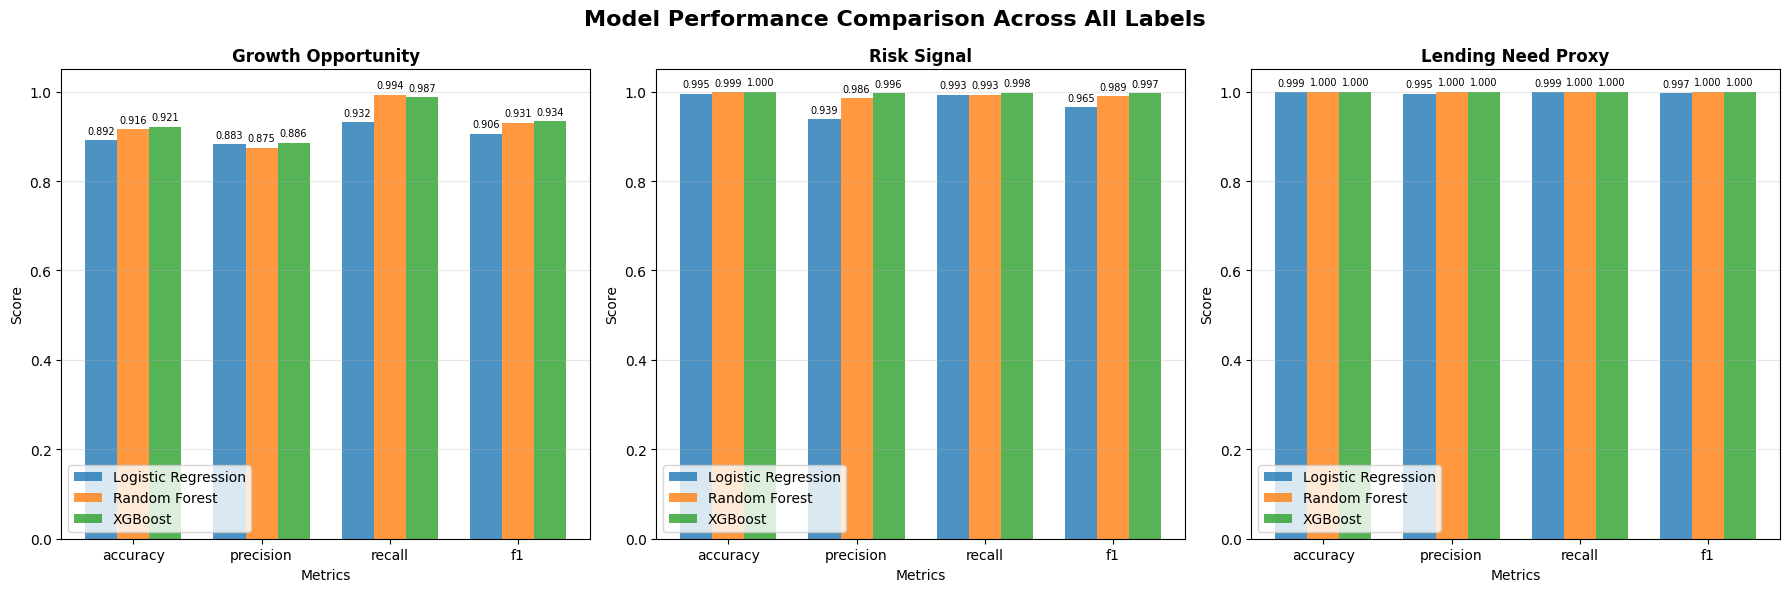

 Saved: output/baseline_performance_chart.png


In [36]:
# CELL 10: VISUALIZE PERFORMANCE COMPARISON
# This cell creates bar charts comparing all models
# across all labels for key metrics.

print("GENERATING PERFORMANCE VISUALIZATIONS")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison Across All Labels', 
             fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = {
    'Logistic Regression': '#1f77b4',  # Blue
    'Random Forest': '#ff7f0e',        # Orange
    'XGBoost': '#2ca02c'               # Green
}

for idx, (label, title) in enumerate([
    ('growth', 'Growth Opportunity'),
    ('risk', 'Risk Signal'),
    ('lending', 'Lending Need Proxy')
]):
    ax = axes[idx]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    for i, model in enumerate(['Logistic Regression', 'Random Forest', 'XGBoost']):
        scores = [all_results[label][model][m] for m in metrics]
        bars = ax.bar(x + (i-1)*width, scores, width, 
                     label=model, color=colors[model], alpha=0.8)
        
        # Add values on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/baseline_performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: output/baseline_performance_chart.png")

GENERATING ROC CURVES


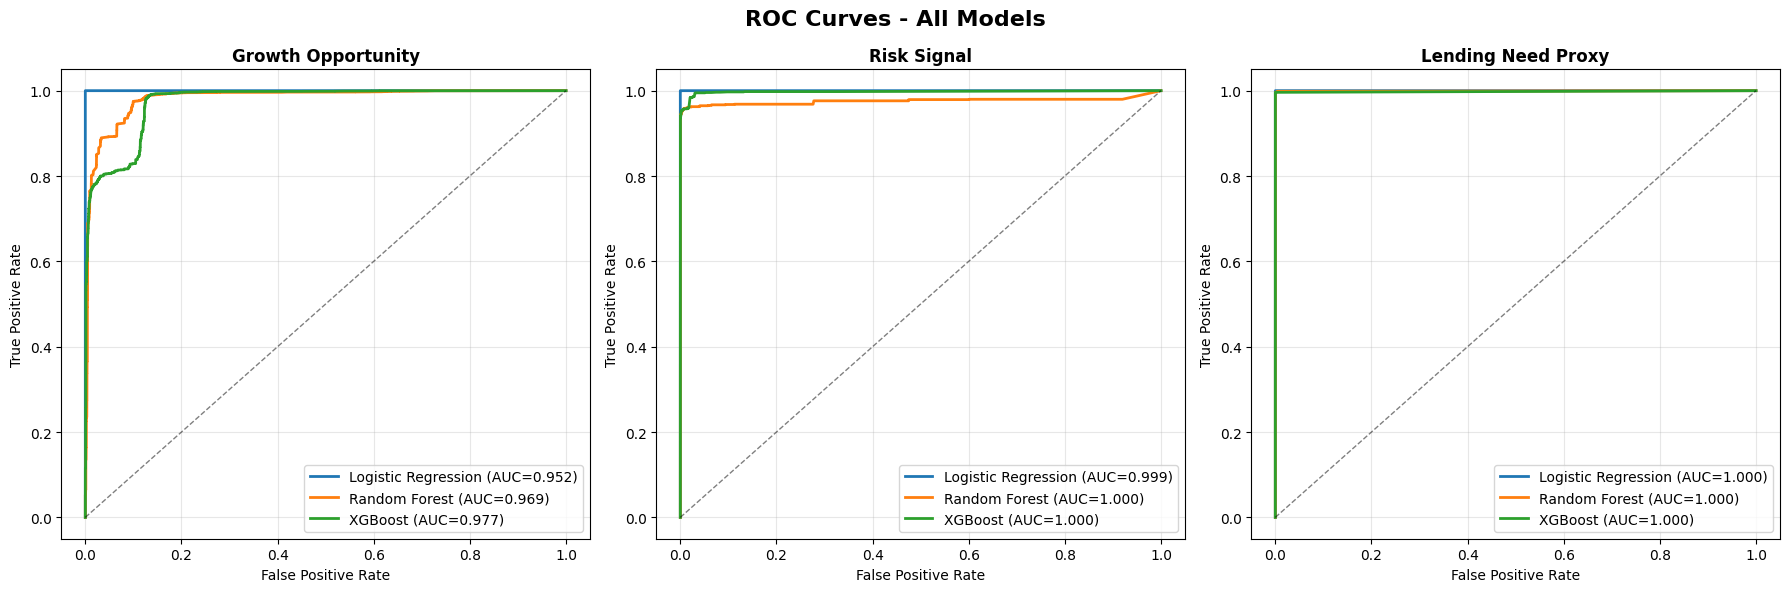

 Saved: output/roc_curves.png


In [37]:
# CELL 11: ROC CURVES FOR ALL MODELS
# This cell plots ROC curves to compare discriminative ability.
# Higher AUC = better at distinguishing between classes.

print("GENERATING ROC CURVES")

all_predictions = {
    'growth': growth_predictions,
    'risk': risk_predictions,
    'lending': lending_predictions
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROC Curves - All Models', fontsize=16, fontweight='bold')

for idx, (label, title) in enumerate([
    ('growth', 'Growth Opportunity'),
    ('risk', 'Risk Signal'),
    ('lending', 'Lending Need Proxy')
]):
    ax = axes[idx]
    
    # Get y_test from any model (all have same y_test)
    y_test = growth_predictions['Logistic Regression']['y_pred']
    if label == 'risk':
        y_test = risk_predictions['Logistic Regression']['y_pred']
    elif label == 'lending':
        y_test = lending_predictions['Logistic Regression']['y_pred']
    
    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        y_prob = all_predictions[label][model]['y_prob']
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = all_results[label][model]['roc_auc']
        ax.plot(fpr, tpr, label=f'{model} (AUC={roc_auc:.3f})', 
                color=colors[model], lw=2)
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: output/roc_curves.png")

In [38]:
# CELL 12: SAVE TRAINED MODELS
# This cell saves all trained models using joblib.
# You can load them later without retraining.

print("SAVING TRAINED MODELS")

import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save models with their scalers
model_data = {
    'growth': {
        'models': growth_models,
        'scaler': scaler_growth,
        'features': GROWTH_FEATURES,
        'results': growth_results
    },
    'risk': {
        'models': risk_models,
        'scaler': scaler_risk,
        'features': RISK_FEATURES,
        'results': risk_results
    },
    'lending': {
        'models': lending_models,
        'scaler': scaler_lending,
        'features': LENDING_FEATURES,
        'results': lending_results
    }
}

# Save each label's data
for label in ['growth', 'risk', 'lending']:
    joblib.dump(model_data[label], f'models/{label}_model_data.joblib')
    print(f"Saved: models/{label}_model_data.joblib")

print("\n Models saved successfully!")
print("To load: model_data = joblib.load('models/growth_model_data.joblib')")

SAVING TRAINED MODELS
Saved: models/growth_model_data.joblib
Saved: models/risk_model_data.joblib
Saved: models/lending_model_data.joblib

 Models saved successfully!
To load: model_data = joblib.load('models/growth_model_data.joblib')


In [ ]:
# CELL 13: GENERATE PREDICTIONS FOR ALL COMPANIES
# This cell applies the trained models to ALL companies
# and creates a ranked priority list.

print("GENERATING PREDICTIONS FOR ALL COMPANIES")

# Create a copy for predictions
df_predictions = df.copy()

# Get the best model for each label
best_model_names = {
    'growth': best_models['growth'],
    'risk': best_models['risk'],
    'lending': best_models['lending']
}

# Model mapping
model_mapping = {
    'growth': growth_models,
    'risk': risk_models,
    'lending': lending_models
}

scaler_mapping = {
    'growth': scaler_growth,
    'risk': scaler_risk,
    'lending': scaler_lending
}

feature_mapping = {
    'growth': GROWTH_FEATURES,
    'risk': RISK_FEATURES,
    'lending': LENDING_FEATURES
}

GENERATING PREDICTIONS FOR ALL COMPANIES


NameError: name 'RISK_FEAT' is not defined